# Movie Audience Prediction — Model Training V2

**Team:** Furkan Fidan | Beyza Nur Selvi | Enes Kocakanat

This notebook addresses the feature engineering shortcomings identified in `model_training.ipynb` (V1) and demonstrates measurable improvements through enhanced feature design.

---

## What Changed in V2?

| # | Feature | V1 Approach | V2 Approach | Where |
|---|---|---|---|---|
| 1 | **`rating`** | One-Hot Encoding | Ordinal encoding (0–4) | `preprocessing.py` ✓ |
| 2 | **`genre`** | First tag only | Multi-hot + `genre_count` | `genre_count` → preprocessing, multi-hot → notebook |
| 3 | **`distributor`** | Mean only | `mean` + `std` + `film_count` + `domestic_ratio` | Leakage-free stats → preprocessing, target-based → notebook |
| 4 | **`holiday_type`** | Binary (0/1) | 5 categories (Ramadan, Kurban, New Year, national, none) | `preprocessing.py` ✓ |
| 5 | **`release_week`** | Not used | ISO week number (1–53) | `preprocessing.py` ✓ |

In [2]:
#
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed/final_movie_data.csv")

print(f"Dataset loaded: {len(df)} films, {df.shape[1]} features")
df.head(10)

Dataset loaded: 1100 films, 19 features


,movie_name,distributor,distributor_film_count,distributor_domestic_ratio,is_domestic,genre,genre_count,is_sequel,holiday_week,holiday_type,release_season,release_year,release_month,release_week,competition_index,runtime_minutes,rating,total_audience,log_total_audience
0,Düğün Dernek 2: Sünnet,CGV Mars,225,0.729,1,Komedi,1,1,0,none,Winter,2015,12,49,4,112.0,2,6073364,15.619423
1,Hızlı ve Öfkeli 7,UIP,271,0.137,0,Aksiyon,1,1,0,none,Spring,2015,4,14,5,137.0,2,2961089,14.901068
2,Kocan Kadar Konuş,UIP,271,0.137,1,Romantik-Komedi,1,0,0,none,Spring,2015,3,12,11,108.0,2,1930677,14.473381
3,Ali Baba ve 7 Cüceler,CGV Mars,225,0.729,1,Komedi,1,0,0,none,Fall,2015,11,46,5,114.0,3,1828311,14.418903
4,Selam: Bahara Yolculuk,CGV Mars,225,0.729,1,Dram,1,0,0,none,Spring,2015,3,11,11,120.0,3,1683497,14.336384
5,Bana Masal Anlatma,UIP,271,0.137,1,"Komedi, Romantik-Komedi",2,0,0,none,Winter,2015,1,2,12,103.0,1,1576979,14.271022
6,Aşk Sana Benzer,CGV Mars,225,0.729,1,"Dram, Romantik",2,0,0,none,Winter,2015,1,4,12,115.0,0,1406620,14.156700
7,Yenilmezler: Ultron Çağı,UIP,271,0.137,0,"Macera, Aksiyon, 3 Boyutlu",3,0,1,1_mayis,Spring,2015,5,18,8,141.0,2,1284848,14.066151
8,Yapışık Kardeşler,CGV Mars,225,0.729,1,Komedi,1,0,0,none,Winter,2015,1,5,12,105.0,2,1014630,13.830035
9,Niyazi Gül Dörtnala,UIP,271,0.137,1,Komedi,1,0,0,none,Spring,2015,5,19,8,106.0,1,994016,13.809509


## Section 1: Feature Validation

The following features are pre-computed by `preprocessing.py` and come ready in the dataset.
This section validates their distributions to ensure the pipeline ran correctly — no recomputation needed here.

- **`rating`** — Age restriction encoded as ordinal integer (0 = General, 4 = 18+)
- **`holiday_type`** — Release window categorized by holiday type (Ramadan, Kurban, New Year, national holidays)
- **`genre_count`** — Number of genre tags per film
- **`release_week`** — ISO week number of the release date (1–53)
- **`distributor_film_count`** — Total number of films distributed by each distributor in the dataset
- **`distributor_domestic_ratio`** — Share of domestic films in each distributor's portfolio (0.0–1.0)

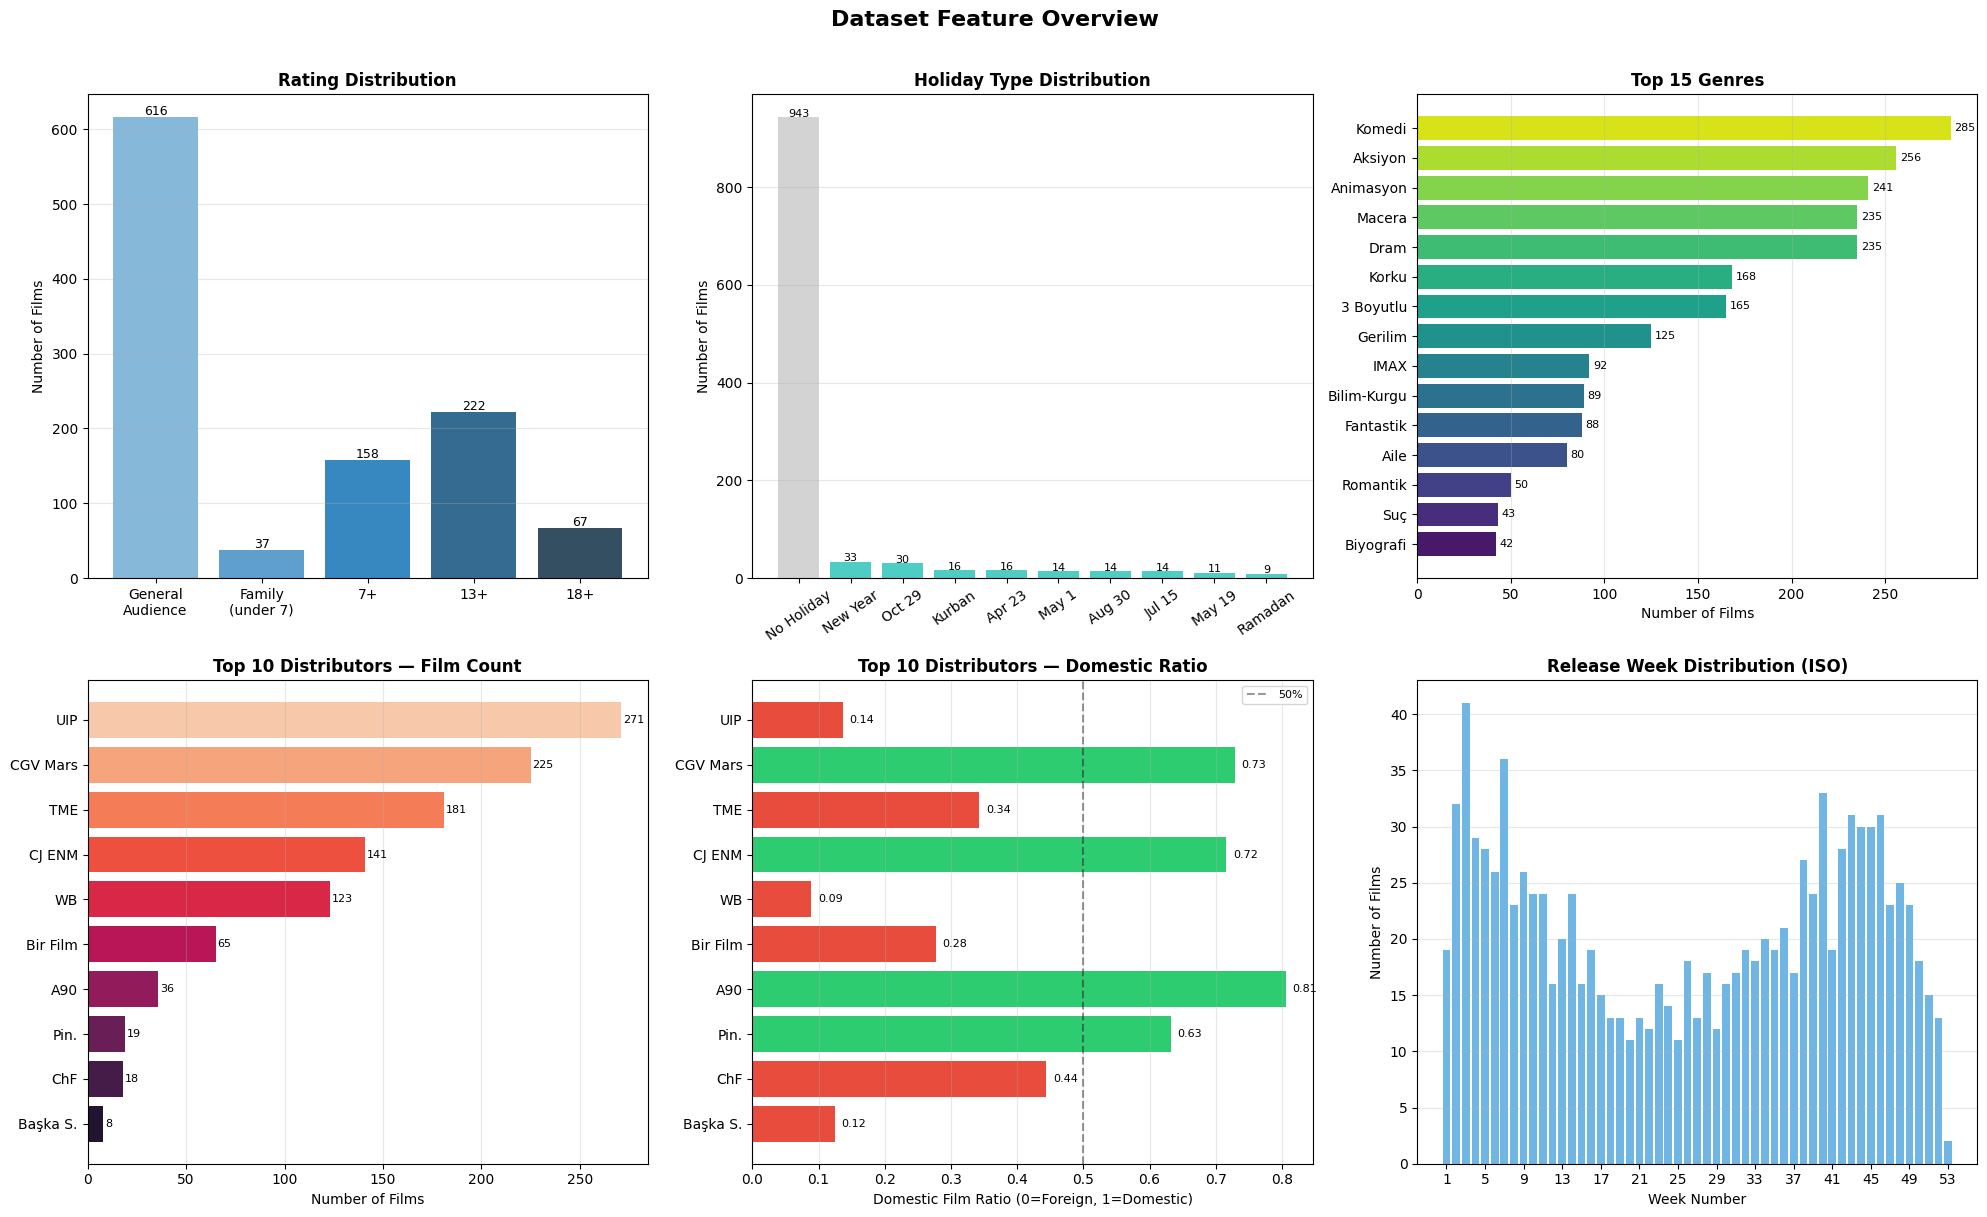

In [3]:
#
RATING_LABELS = {
    0: "General\nAudience", 1: "Family\n(under 7)", 
    2: "7+", 3: "13+", 4: "18+"
}

HOLIDAY_LABELS = {
    'none': 'No Holiday', 'ramazan_bayrami': 'Ramadan',
    'kurban_bayrami': 'Kurban', 'yilbasi': 'New Year',
    '23_nisan': 'Apr 23', '1_mayis': 'May 1',
    '19_mayis': 'May 19', '15_temmuz': 'Jul 15',
    '30_agustos': 'Aug 30', '29_ekim': 'Oct 29'
}

# Genre counts
genre_counts = {}
for g in df['genre']:
    for tag in str(g).split(','):
        t = tag.strip()
        if t and t != 'Bilinmiyor':
            genre_counts[t] = genre_counts.get(t, 0) + 1
genre_series = pd.Series(genre_counts).sort_values(ascending=False).head(15)

top_dist = (
    df.groupby('distributor')[['distributor_film_count', 'distributor_domestic_ratio']]
    .first()
    .sort_values('distributor_film_count', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dataset Feature Overview', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Rating ─────────────────────────────────────────────────
ax = axes[0, 0]
rating_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(
    [RATING_LABELS[i] for i in rating_counts.index],
    rating_counts.values,
    color=sns.color_palette('Blues_d', len(rating_counts))
)
ax.set_title('Rating Distribution', fontweight='bold')
ax.set_ylabel('Number of Films')
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=9)

# ── 2. Holiday Type ───────────────────────────────────────────
ax = axes[0, 1]
holiday_counts = df['holiday_type'].value_counts()
labels = [HOLIDAY_LABELS.get(h, h) for h in holiday_counts.index]
colors = ['#d3d3d3' if h == 'none' else '#4ECDC4' for h in holiday_counts.index]
bars = ax.bar(labels, holiday_counts.values, color=colors)
ax.set_title('Holiday Type Distribution', fontweight='bold')
ax.set_ylabel('Number of Films')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', fontsize=8)

# ── 3. Genre ──────────────────────────────────────────────────
ax = axes[0, 2]
ax.barh(genre_series.index[::-1], genre_series.values[::-1],
        color=sns.color_palette('viridis', len(genre_series)))
ax.set_title('Top 15 Genres', fontweight='bold')
ax.set_xlabel('Number of Films')
ax.grid(axis='x', alpha=0.3)
for i, val in enumerate(genre_series.values[::-1]):
    ax.text(val + 2, i, str(val), va='center', fontsize=8)

# ── 4. Distributor — Film Count ───────────────────────────────
ax = axes[1, 0]
bars = ax.barh(top_dist.index[::-1], top_dist['distributor_film_count'][::-1],
               color=sns.color_palette('rocket', len(top_dist)))
ax.set_title('Top 10 Distributors — Film Count', fontweight='bold')
ax.set_xlabel('Number of Films')
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=8)

# ── 5. Distributor — Domestic Ratio ──────────────────────────
ax = axes[1, 1]
colors = ['#2ecc71' if r >= 0.5 else '#e74c3c' for r in top_dist['distributor_domestic_ratio']]
bars = ax.barh(top_dist.index[::-1], top_dist['distributor_domestic_ratio'][::-1], color=colors[::-1])
ax.set_title('Top 10 Distributors — Domestic Ratio', fontweight='bold')
ax.set_xlabel('Domestic Film Ratio (0=Foreign, 1=Domestic)')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.4, label='50%')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}", va='center', fontsize=8)

# ── 6. Release Week ───────────────────────────────────────────
ax = axes[1, 2]
week_counts = df['release_week'].value_counts().sort_index()
ax.bar(week_counts.index, week_counts.values, color='#3498db', alpha=0.7, width=0.8)
ax.set_title('Release Week Distribution (ISO)', fontweight='bold')
ax.set_xlabel('Week Number')
ax.set_ylabel('Number of Films')
ax.set_xticks(range(1, 54, 4))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 2: Genre Multi-Hot Encoding

In V1, only the **first genre tag** was used — a film labeled `"Comedy, Drama"` was treated as `"Comedy"` only, discarding all additional genre information.

In V2, we apply **multi-hot encoding**: each genre becomes its own binary column (`is_genre_comedy`, `is_genre_drama`, etc.), allowing a film to belong to multiple genres simultaneously.

- **`genre_count`** — already computed in `preprocessing.py`, tells the model how many genres a film spans (broader genre scope may signal different audience appeal)
- **`is_genre_*`** — one binary column per unique genre tag, created here since it is a model-specific encoding decision

Unique genre tags: 29  |  Binary columns created: 29


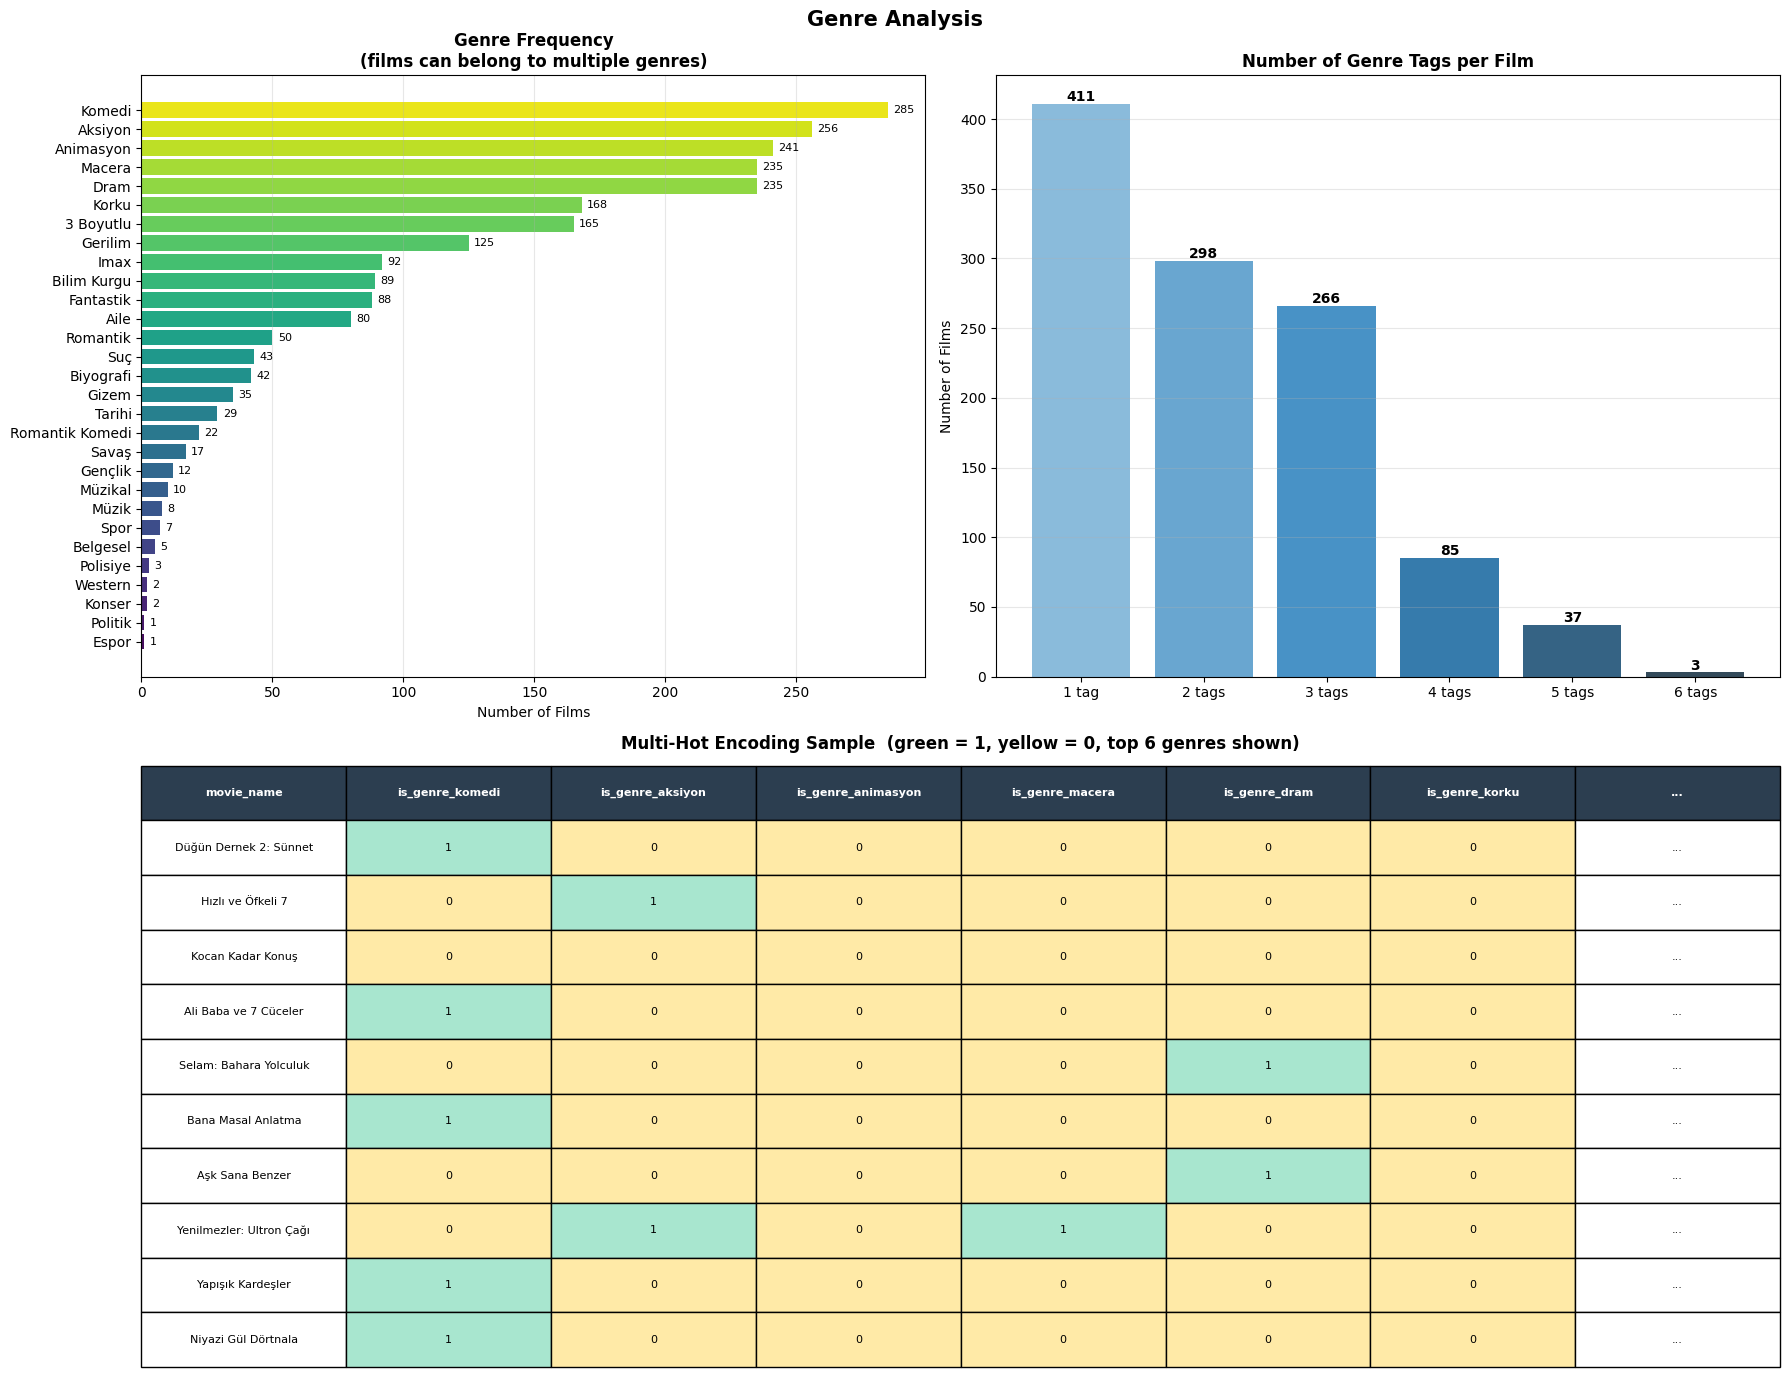

In [4]:
# Collect all unique genre tags from the dataset
all_genres = set()
for g in df['genre']:
    for tag in str(g).split(','):
        t = tag.strip()
        if t and t != 'Bilinmiyor':
            all_genres.add(t)
all_genres = sorted(all_genres)

# Create one binary column per genre tag
def make_col(tag):
    return 'is_genre_' + tag.lower().replace(' ', '_').replace('-', '_')

for genre in all_genres:
    col = make_col(genre)
    df[col] = df['genre'].apply(
        lambda x: 1 if genre in [t.strip() for t in str(x).split(',')] else 0
    )

genre_cols = [c for c in df.columns if c.startswith('is_genre_')]
genre_freq = df[genre_cols].sum().sort_values(ascending=False)
genre_freq.index = [i.replace('is_genre_', '').replace('_', ' ').title() for i in genre_freq.index]

print(f"Unique genre tags: {len(all_genres)}  |  Binary columns created: {len(genre_cols)}")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Genre Analysis', fontsize=15, fontweight='bold')

# ── 1. Genre frequency ────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
bars = ax1.barh(
    genre_freq.index[::-1], genre_freq.values[::-1],
    color=sns.color_palette('viridis', len(genre_freq))
)
ax1.set_title('Genre Frequency\n(films can belong to multiple genres)', fontweight='bold')
ax1.set_xlabel('Number of Films')
ax1.grid(axis='x', alpha=0.3)
for bar in bars:
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             str(int(bar.get_width())), va='center', fontsize=8)

# ── 2. Genre count per film ───────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
gc = df['genre_count'].value_counts().sort_index()
bars2 = ax2.bar(
    [f"{n} tag{'s' if n != 1 else ''}" for n in gc.index],
    gc.values,
    color=sns.color_palette('Blues_d', len(gc))
)
ax2.set_title('Number of Genre Tags per Film', fontweight='bold')
ax2.set_ylabel('Number of Films')
ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             str(int(bar.get_height())), ha='center', fontweight='bold', fontsize=10)

# ── 3. Multi-hot encoding sample table ───────────────────────
ax3 = fig.add_subplot(2, 1, 2)
ax3.axis('off')

# Top 6 genre columns + "..." indicator
top_cols  = [make_col(g) for g in genre_freq.head(6).index.tolist()]
sample    = df[['movie_name'] + top_cols].head(10).copy()
sample.columns = ['movie_name'] + top_cols  # keep is_genre_* names as-is

# Add "..." column
sample['...'] = '...'

table = ax3.table(
    cellText=sample.values,
    colLabels=list(sample.columns),
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)

# Style header
for j in range(len(sample.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style value cells
for i in range(1, len(sample) + 1):
    for j in range(1, len(sample.columns)):
        val = sample.values[i - 1][j]
        if val == 1:
            table[i, j].set_facecolor('#a8e6cf')
        elif val == 0:
            table[i, j].set_facecolor('#ffeaa7')

ax3.set_title('Multi-Hot Encoding Sample  (green = 1, yellow = 0, top 6 genres shown)',
              fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


## Section 3: Model Pipeline

This section covers the full training pipeline for V2. The steps below are designed to avoid **data leakage** — the model must never see test set information during training.

**Steps:**

1. **Train / Test Split** — Same `random_state=42` as V1 to ensure both models are evaluated on identical test films (fair comparison)

2. **Distributor Target Encoding** — `distributor_power` (mean) and `distributor_std` (standard deviation) are computed **using training data only**, then mapped to the test set. This prevents the model from learning test set patterns through the distributor statistics.
   - `distributor_film_count` and `distributor_domestic_ratio` are already in the dataset (computed in `preprocessing.py` without using the target variable — no leakage risk)

3. **One-Hot Encoding** — Applied to `release_season` and `holiday_type` (remaining categorical columns). All binary/numeric features (`is_genre_*`, `rating`, `release_week`, etc.) are passed as-is.

4. **Model Training** — Same architecture as V1 for a fair comparison:
   - `RandomForestRegressor` (300 trees, max depth 10)
   - `GradientBoostingRegressor` (300 estimators, learning rate 0.05)
   - Combined via `VotingRegressor`

Train set : 880 films
Test set  : 220 films

Feature count (before OHE): 44


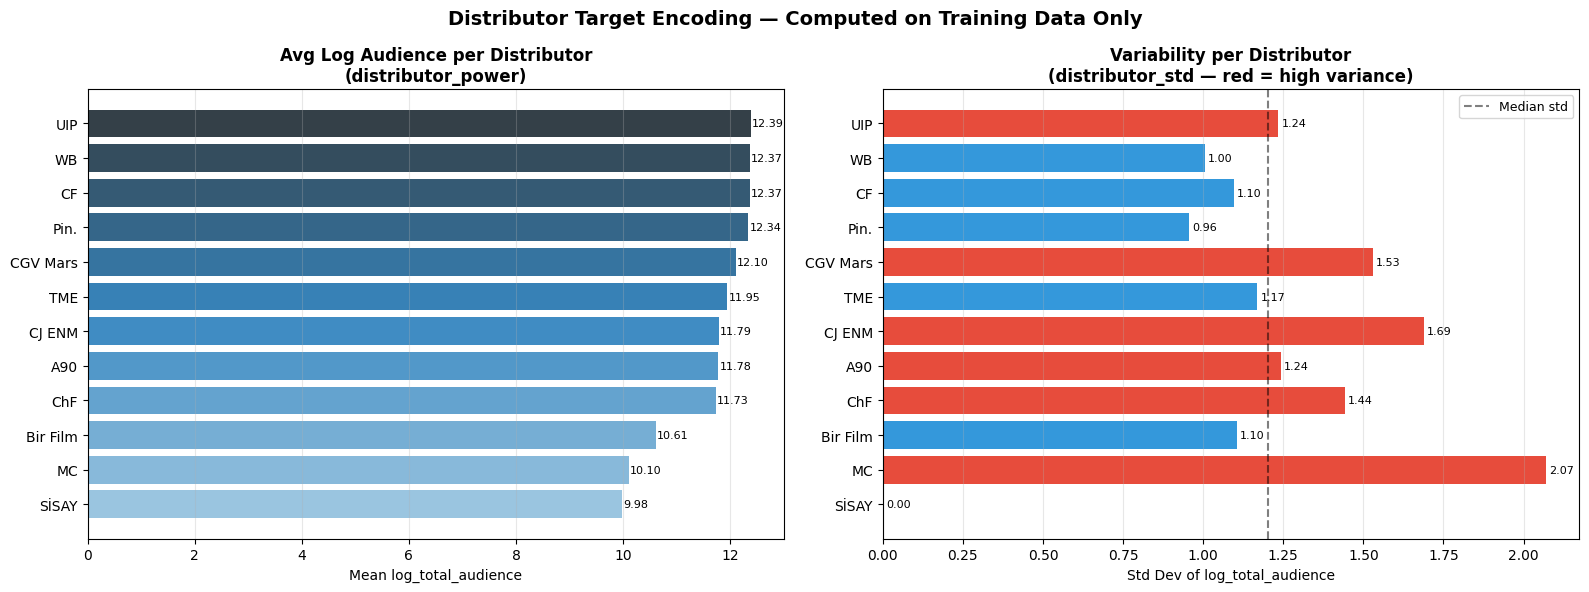

High std = distributor releases both blockbusters and small films
Low std  = distributor's performance is more predictable


In [5]:
# Columns excluded from the model:
#   movie_name     — identifier only, not a feature
#   genre          — replaced by multi-hot is_genre_* columns
#   holiday_week   — fully captured by holiday_type (redundant)
#   total_audience — raw version of the target variable → data leakage!
#   distributor    — kept for now, dropped after target encoding below
DROP_COLS = ['movie_name', 'genre', 'holiday_week', 'total_audience']

X = df.drop(['log_total_audience'] + DROP_COLS, axis=1)
y = df['log_total_audience']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = X_train.copy(), X_test.copy()

print(f"Train set : {len(X_train)} films")
print(f"Test set  : {len(X_test)} films")

# ── Distributor target encoding ───────────────────────────────
# Computed on training data only — mapped to test set afterwards.
# Unseen distributors in test set receive the global training mean/std.
dist_means = y_train.groupby(X_train['distributor']).mean()
dist_stds  = y_train.groupby(X_train['distributor']).std().fillna(0)

fallback_mean = float(y_train.mean())
fallback_std  = float(dist_stds.mean())

for split in [X_train, X_test]:
    split['distributor_power'] = split['distributor'].map(dist_means).fillna(fallback_mean)
    split['distributor_std']   = split['distributor'].map(dist_stds).fillna(fallback_std)

X_train = X_train.drop('distributor', axis=1)
X_test  = X_test.drop('distributor', axis=1)

print(f"\nFeature count (before OHE): {X_train.shape[1]}")

# ── Distributor visualization ─────────────────────────────────
summary = pd.DataFrame({
    'power': dist_means,
    'std':   dist_stds,
}).sort_values('power', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distributor Target Encoding — Computed on Training Data Only',
             fontsize=14, fontweight='bold')

# 1. Average performance
ax = axes[0]
bars = ax.barh(
    summary.index[::-1], summary['power'][::-1],
    color=sns.color_palette('Blues_d', len(summary))
)
ax.set_title('Avg Log Audience per Distributor\n(distributor_power)', fontweight='bold')
ax.set_xlabel('Mean log_total_audience')
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}", va='center', fontsize=8)

# 2. Variability
ax = axes[1]
colors = ['#e74c3c' if s > summary['std'].median() else '#3498db'
          for s in summary['std'][::-1]]
bars2 = ax.barh(
    summary.index[::-1], summary['std'][::-1],
    color=colors
)
ax.set_title('Variability per Distributor\n(distributor_std — red = high variance)',
             fontweight='bold')
ax.set_xlabel('Std Dev of log_total_audience')
ax.axvline(summary['std'].median(), color='black', linestyle='--',
           alpha=0.5, label='Median std')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
for bar in bars2:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.2f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("High std = distributor releases both blockbusters and small films")
print("Low std  = distributor's performance is more predictable")

In [6]:
# ── Final One-Hot Encoding ────────────────────────────────────
# Only string categorical columns need OHE.
# release_season (4 categories) and holiday_type (10 categories)
# All other features (is_genre_*, rating, release_week, etc.) are already numeric.
OHE_COLS = ['release_season', 'holiday_type']

X_train_v2 = pd.get_dummies(X_train, columns=OHE_COLS, drop_first=False)
X_test_v2  = pd.get_dummies(X_test,  columns=OHE_COLS, drop_first=False)
X_test_v2  = X_test_v2.reindex(columns=X_train_v2.columns, fill_value=0)

print(f"Features before OHE : {X_train.shape[1]}")
print(f"Features after OHE  : {X_train_v2.shape[1]}  (+{X_train_v2.shape[1] - X_train.shape[1]} from OHE expansion)")

# ── Model Training ────────────────────────────────────────────
# Same architecture and hyperparameters as V1 — only features differ.
# This ensures the performance difference is purely due to feature engineering.
rf_v2    = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
gb_v2    = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_v2 = VotingRegressor([('rf', rf_v2), ('gb', gb_v2)])

print("\nTraining V2 model...")
model_v2.fit(X_train_v2, y_train)

y_pred_v2 = model_v2.predict(X_test_v2)
r2_v2     = r2_score(y_test, y_pred_v2)
mae_v2    = mean_absolute_error(y_test, y_pred_v2)

print("\n" + "=" * 42)
print(f"  V2 Model Results")
print("=" * 42)
print(f"  R² Score : {r2_v2:.4f}  (1.0 = perfect)")
print(f"  MAE      : {mae_v2:.4f}  (log scale)")
print("=" * 42)

Features before OHE : 44
Features after OHE  : 56  (+12 from OHE expansion)

Training V2 model...

  V2 Model Results
  R² Score : 0.5748  (1.0 = perfect)
  MAE      : 0.7020  (log scale)


## Section 4: Model Results

This section evaluates the V2 model's performance on the **held-out test set** (20% of the data, never seen during training).

- **R² Score** — measures how well predictions explain the variance in actual audience numbers (1.0 = perfect, 0 = predicts only the mean)
- **MAE** — average absolute error in log scale; since the target is log-transformed, an MAE of 0.7 roughly means predictions are off by a factor of ~2× on average
- **Actual vs Predicted** — points close to the diagonal line indicate accurate predictions
- **Residuals** — the difference between actual and predicted values; a good model has residuals centered around 0

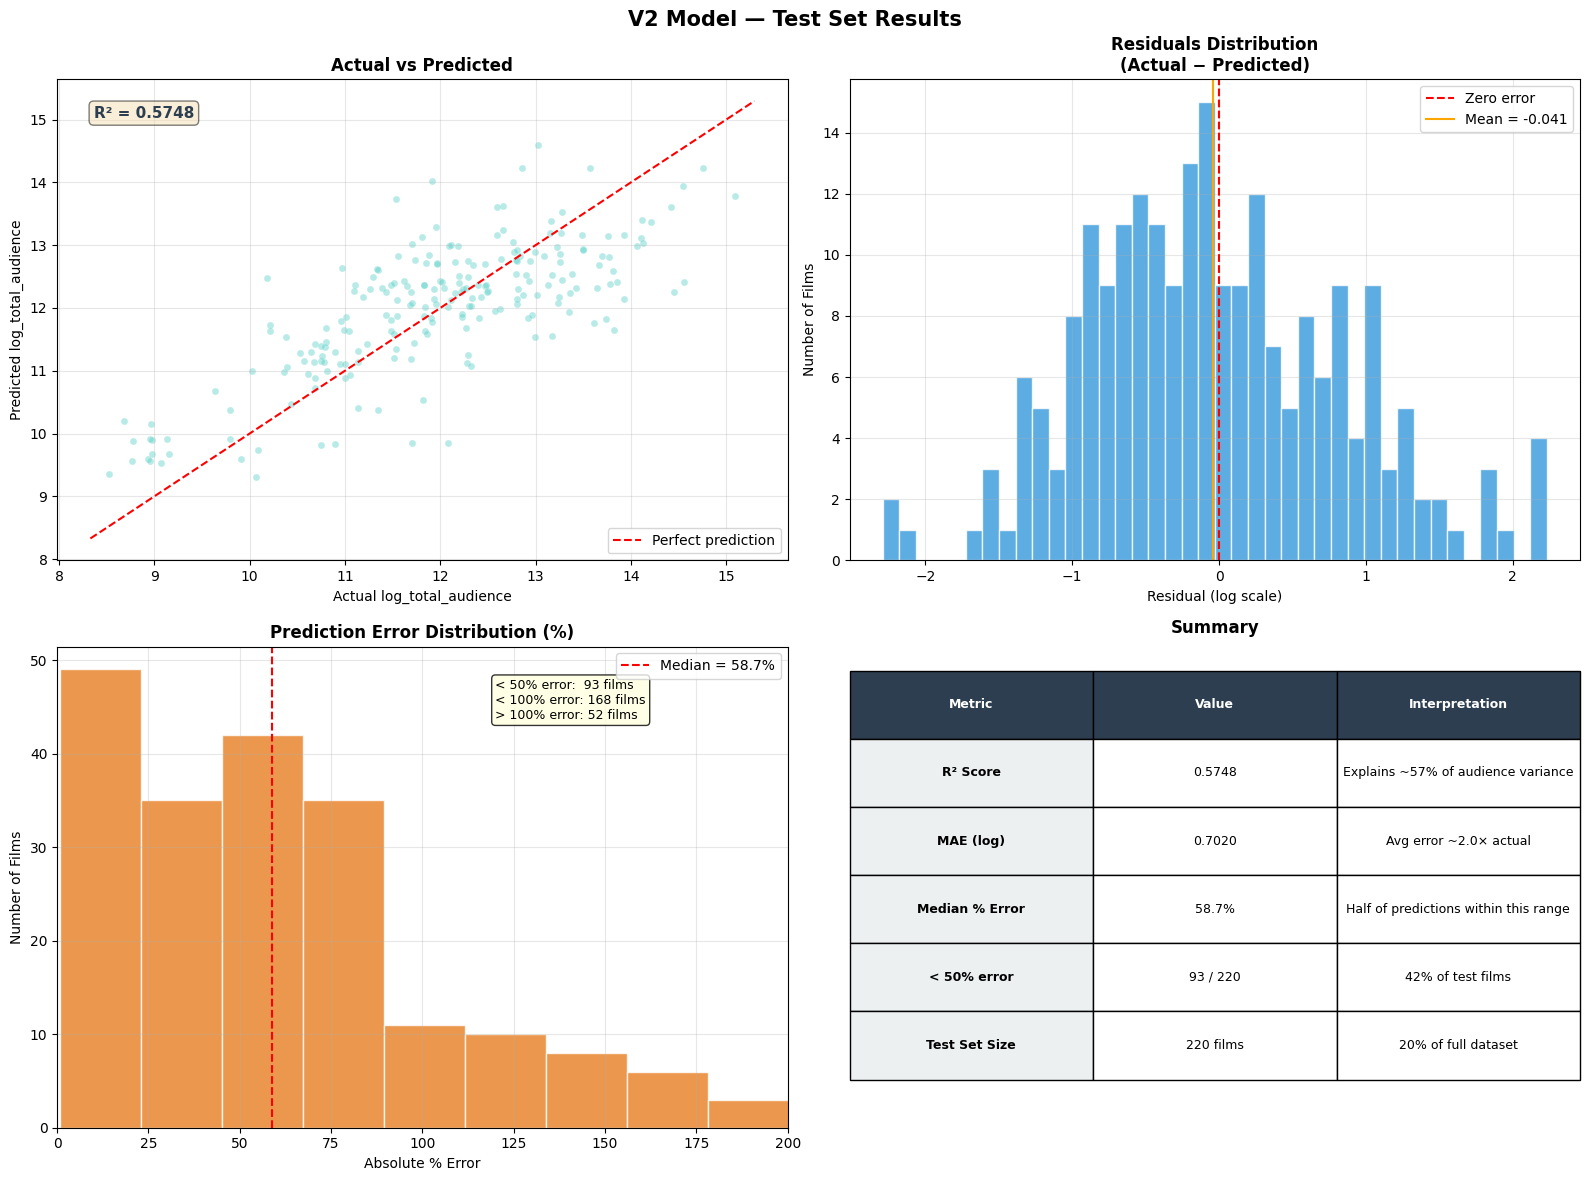

In [7]:
#
residuals  = y_test - y_pred_v2
errors_pct = (abs(np.exp(y_test.values) - np.exp(y_pred_v2)) / np.exp(y_test.values) * 100)
med_err    = np.median(errors_pct)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('V2 Model — Test Set Results', fontsize=15, fontweight='bold')

# ── 1. Actual vs Predicted ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_test, y_pred_v2, alpha=0.4, color='#4ECDC4', s=25, edgecolors='white', linewidth=0.3)
lims = [y_test.min() - 0.2, y_test.max() + 0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Actual vs Predicted', fontweight='bold')
ax.set_xlabel('Actual log_total_audience')
ax.set_ylabel('Predicted log_total_audience')
ax.legend()
ax.grid(alpha=0.3)
ax.text(0.05, 0.92, f'R² = {r2_v2:.4f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color='#2c3e50',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ── 2. Residuals distribution ─────────────────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(float(np.mean(residuals)), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean = {float(np.mean(residuals)):.3f}')
ax.set_title('Residuals Distribution\n(Actual − Predicted)', fontweight='bold')
ax.set_xlabel('Residual (log scale)')
ax.set_ylabel('Number of Films')
ax.legend()
ax.grid(alpha=0.3)

# ── 3. Error % distribution ───────────────────────────────────
ax = axes[1, 0]
ax.hist(errors_pct, bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
ax.axvline(med_err, color='red', linestyle='--', linewidth=1.5,
           label=f'Median = {med_err:.1f}%')
ax.set_title('Prediction Error Distribution (%)', fontweight='bold')
ax.set_xlabel('Absolute % Error')
ax.set_ylabel('Number of Films')
ax.set_xlim(0, 200)
ax.legend()
ax.grid(alpha=0.3)
ax.text(0.6, 0.85,
        f"< 50% error:  {(errors_pct < 50).sum()} films\n"
        f"< 100% error: {(errors_pct < 100).sum()} films\n"
        f"> 100% error: {(errors_pct >= 100).sum()} films",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── 4. Metrics summary table ──────────────────────────────────
ax = axes[1, 1]
ax.axis('off')

metrics = [
    ['Metric',           'Value',                              'Interpretation'],
    ['R² Score',         f'{r2_v2:.4f}',                       'Explains ~57% of audience variance'],
    ['MAE (log)',        f'{mae_v2:.4f}',                       f'Avg error ~{np.exp(mae_v2):.1f}× actual'],
    ['Median % Error',  f'{med_err:.1f}%',                     'Half of predictions within this range'],
    ['< 50% error',     f'{(errors_pct < 50).sum()} / {len(errors_pct)}',
                                                                f'{(errors_pct < 50).mean()*100:.0f}% of test films'],
    ['Test Set Size',   f'{len(y_test)} films',                '20% of full dataset'],
]

table = ax.table(cellText=metrics[1:], colLabels=metrics[0],
                 cellLoc='center', loc='center', bbox=[0, 0.1, 1, 0.85])
table.auto_set_font_size(False)
table.set_fontsize(9)
for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(metrics)):
    table[i, 0].set_facecolor('#ecf0f1')
    table[i, 0].set_text_props(fontweight='bold')
ax.set_title('Summary', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## Section 5: Error Analysis

Understanding where the model fails is as important as measuring overall performance.
This section examines the prediction errors across the test set to identify patterns and limitations.

**Key questions:**
- Which films are hardest to predict, and why?
- Are errors systematic (e.g., always underestimating blockbusters)?
- What do the worst predictions have in common — distributor, genre, release window?

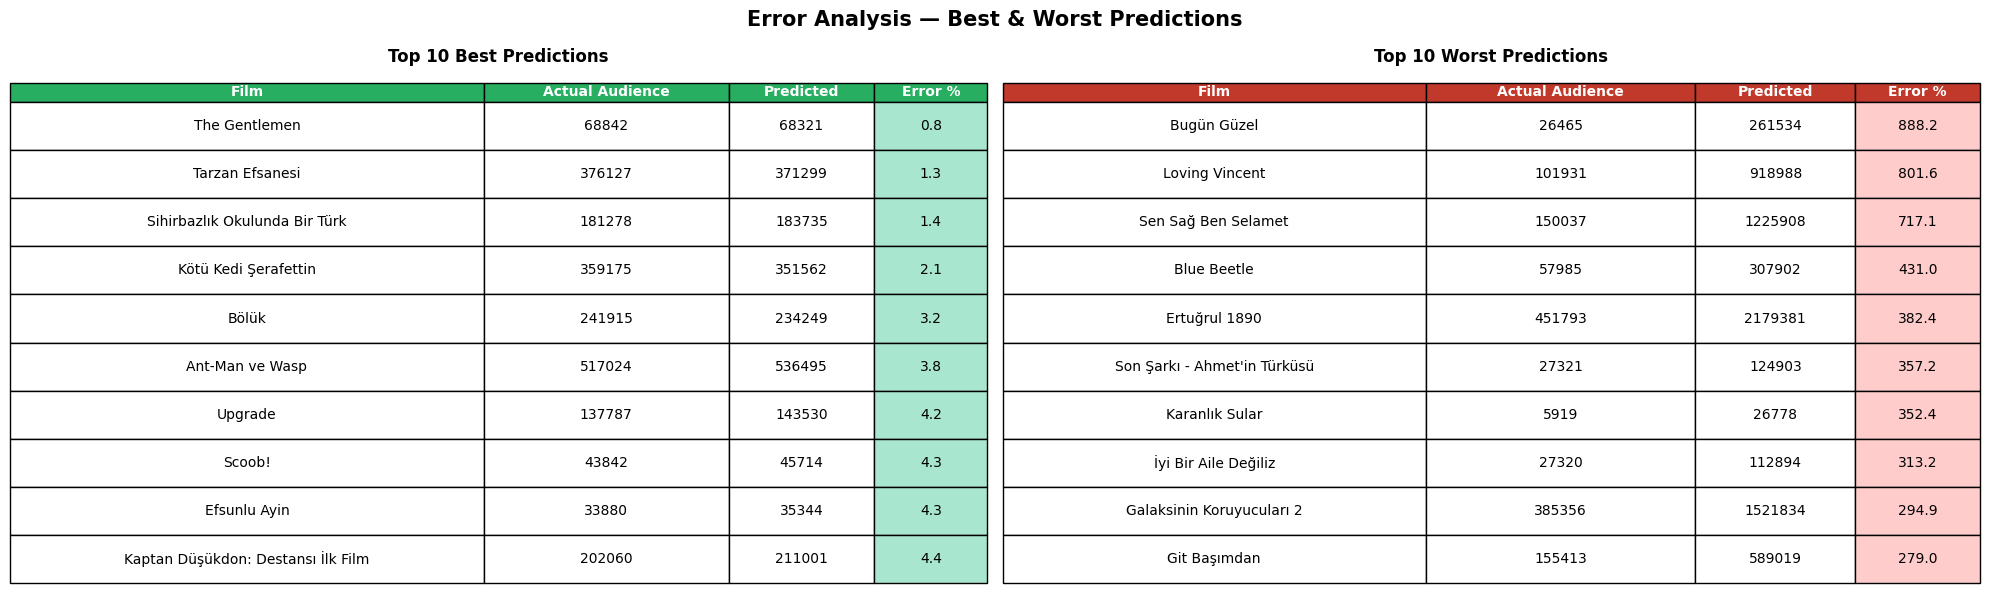

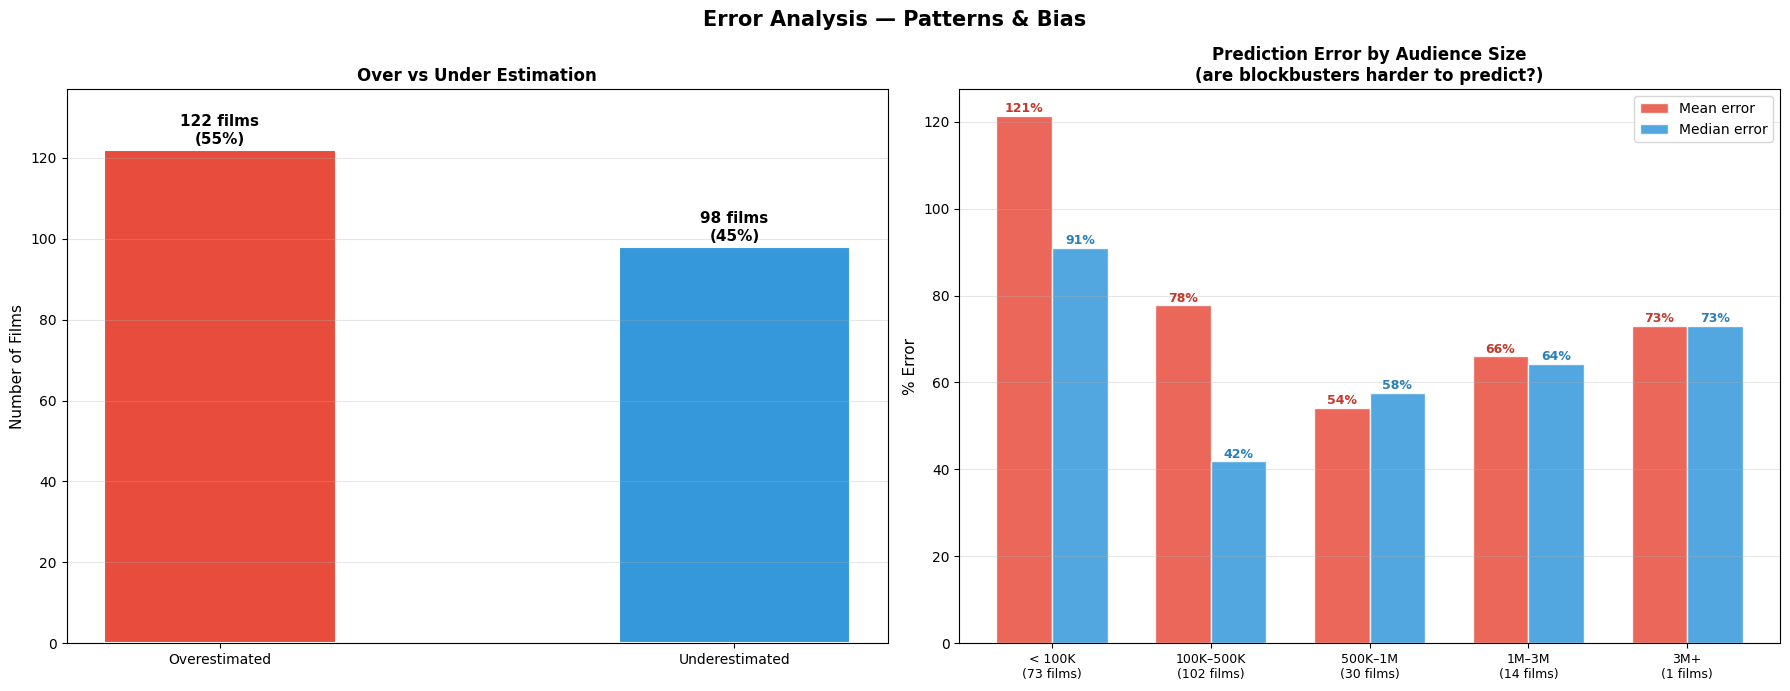

In [8]:
#
results = pd.DataFrame({
    'movie_name':  df.loc[X_test.index, 'movie_name'].values,
    'distributor': df.loc[X_test.index, 'distributor'].values,
    'genre':       df.loc[X_test.index, 'genre'].values,
    'actual':      np.exp(y_test.values).astype(int),
    'predicted':   np.exp(y_pred_v2).astype(int),
})
results['error_pct'] = (abs(results['actual'] - results['predicted']) / results['actual'] * 100).round(1)
results['overunder'] = np.where(results['predicted'] > results['actual'], 'Over', 'Under')

best  = results.nsmallest(10, 'error_pct')
worst = results.nlargest(10, 'error_pct')

# ── Figure 1: Best & Worst tables ────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(20, 6))
fig1.suptitle('Error Analysis — Best & Worst Predictions', fontsize=15, fontweight='bold')

for ax, data, title, header_color, cell_color in [
    (axes1[0], best,  'Top 10 Best Predictions',  '#27ae60', '#a8e6cf'),
    (axes1[1], worst, 'Top 10 Worst Predictions', '#c0392b', '#ffcccc'),
]:
    ax.axis('off')
    tbl = ax.table(
        cellText=data[['movie_name', 'actual', 'predicted', 'error_pct']].values,
        colLabels=['Film', 'Actual Audience', 'Predicted', 'Error %'],
        cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width([0, 1, 2, 3])
    for j in range(4):
        tbl[0, j].set_facecolor(header_color)
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(data) + 1):
        tbl[i, 3].set_facecolor(cell_color)
        for j in range(4):
            tbl[i, j].set_height(0.09)
    ax.set_title(title, fontweight='bold', fontsize=12, pad=15)

plt.tight_layout()
plt.show()

# ── Figure 2: Over/Under + Audience bucket ────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))
fig2.suptitle('Error Analysis — Patterns & Bias', fontsize=15, fontweight='bold')

# Over vs Under
ax = axes2[0]
over  = (results['overunder'] == 'Over').sum()
under = (results['overunder'] == 'Under').sum()
bars  = ax.bar(['Overestimated', 'Underestimated'], [over, under],
               color=['#e74c3c', '#3498db'], width=0.45, edgecolor='white', linewidth=1.5)
ax.set_title('Over vs Under Estimation', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Films', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(over, under) + 15)
for bar, val in zip(bars, [over, under]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val} films\n({val/len(results)*100:.0f}%)",
            ha='center', fontweight='bold', fontsize=11)

# Error by audience size
ax = axes2[1]
bins   = [0, 100_000, 500_000, 1_000_000, 3_000_000, float('inf')]
labels = ['< 100K', '100K–500K', '500K–1M', '1M–3M', '3M+']
results['audience_bucket'] = pd.cut(results['actual'], bins=bins, labels=labels)
bucket_stats = results.groupby('audience_bucket', observed=True)['error_pct'].agg(['mean', 'median', 'count'])

x     = np.arange(len(labels))
width = 0.35
bars1 = ax.bar(x - width/2, bucket_stats['mean'],   width=width,
               label='Mean error',   color='#e74c3c', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, bucket_stats['median'], width=width,
               label='Median error', color='#3498db', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{l}\n({int(bucket_stats['count'][l])} films)" for l in labels], fontsize=9
)
ax.set_title('Prediction Error by Audience Size\n(are blockbusters harder to predict?)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('% Error', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.0f}%", ha='center', fontsize=9, color='#c0392b', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.0f}%", ha='center', fontsize=9, color='#2980b9', fontweight='bold')

plt.tight_layout()
plt.show()

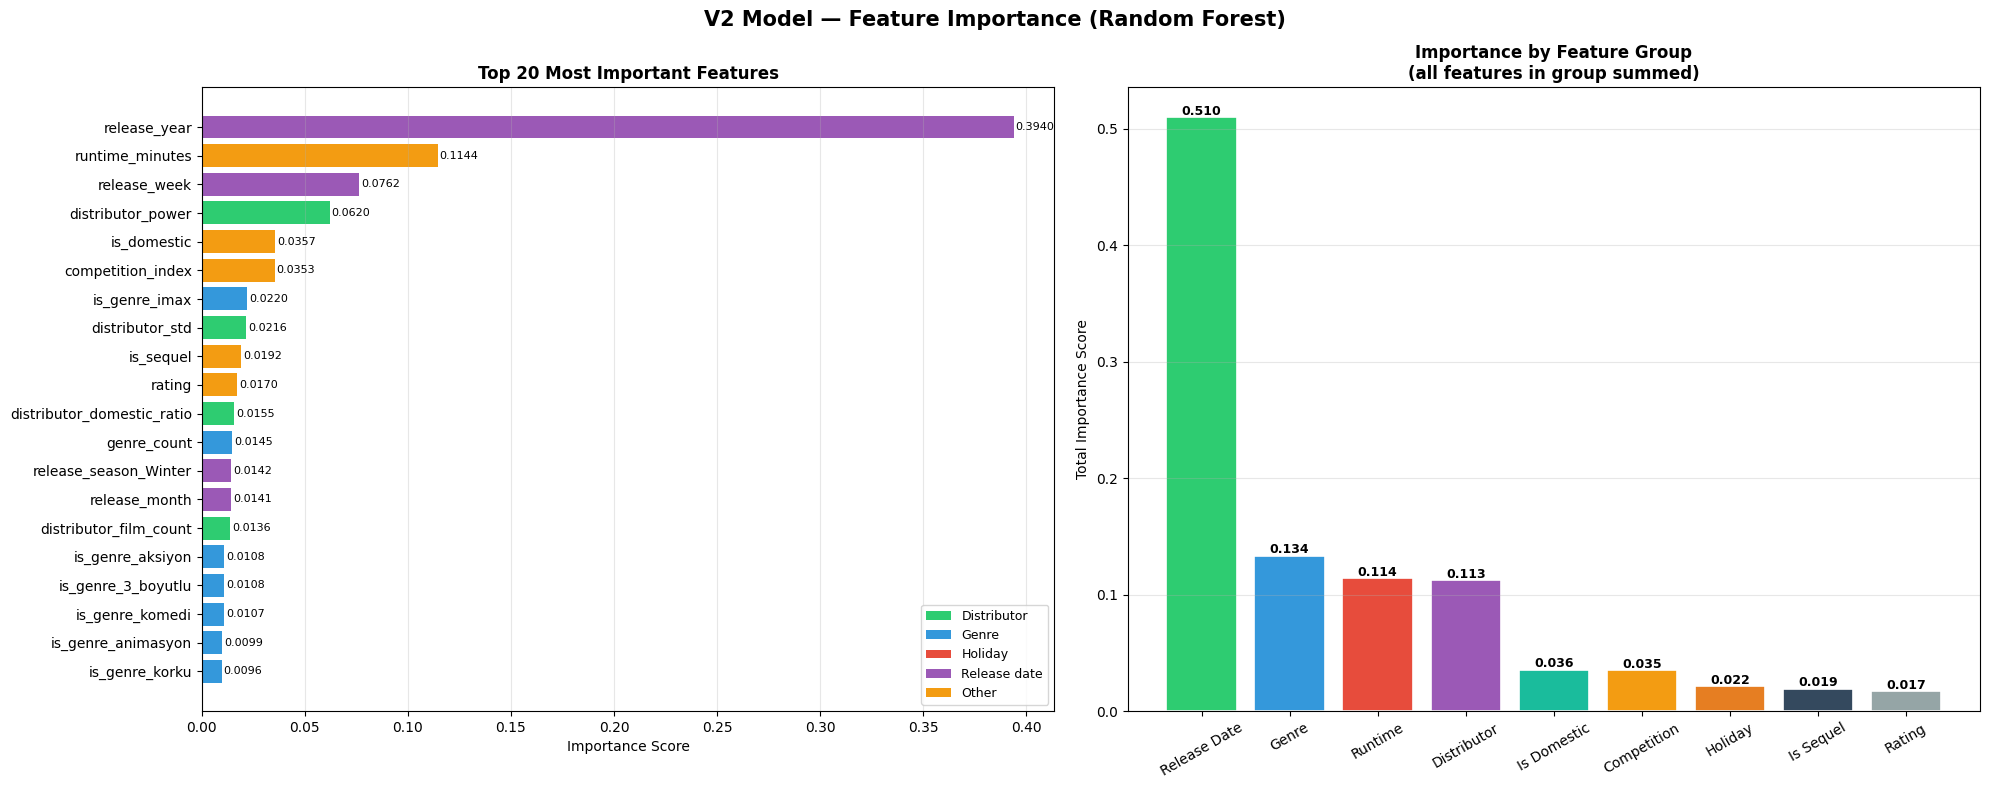

In [9]:
# ── Feature Importance (Random Forest) ───────────────────────
rf_model = model_v2.estimators_[0]
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train_v2.columns
).sort_values(ascending=False)

top_n    = 20
top_feat = feat_imp.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('V2 Model — Feature Importance (Random Forest)', fontsize=15, fontweight='bold')

# ── 1. Top 20 bar chart ───────────────────────────────────────
ax = axes[0]
colors = ['#2ecc71' if 'distributor' in f
          else '#3498db' if 'genre' in f
          else '#e74c3c' if 'holiday' in f
          else '#9b59b6' if 'release' in f
          else '#f39c12'
          for f in top_feat.index]

bars = ax.barh(top_feat.index[::-1], top_feat.values[::-1], color=colors[::-1])
ax.set_title(f'Top {top_n} Most Important Features', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.4f}", va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Distributor'),
    Patch(facecolor='#3498db', label='Genre'),
    Patch(facecolor='#e74c3c', label='Holiday'),
    Patch(facecolor='#9b59b6', label='Release date'),
    Patch(facecolor='#f39c12', label='Other'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

# ── 2. Feature group importance (aggregated) ─────────────────
ax = axes[1]

groups = {
    'Distributor':    feat_imp[[f for f in feat_imp.index if 'distributor' in f]].sum(),
    'Genre':          feat_imp[[f for f in feat_imp.index if 'genre' in f or 'is_genre' in f]].sum(),
    'Holiday':        feat_imp[[f for f in feat_imp.index if 'holiday' in f]].sum(),
    'Release Date':   feat_imp[[f for f in feat_imp.index if 'release' in f]].sum(),
    'Competition':    feat_imp[[f for f in feat_imp.index if 'competition' in f]].sum(),
    'Runtime':        feat_imp[[f for f in feat_imp.index if 'runtime' in f]].sum(),
    'Rating':         feat_imp[[f for f in feat_imp.index if f == 'rating']].sum(),
    'Is Domestic':    feat_imp[[f for f in feat_imp.index if 'domestic' in f and 'ratio' not in f]].sum(),
    'Is Sequel':      feat_imp[[f for f in feat_imp.index if 'sequel' in f]].sum(),
}
group_series = pd.Series(groups).sort_values(ascending=False)

group_colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6',
                '#1abc9c', '#f39c12', '#e67e22', '#34495e', '#95a5a6']
bars2 = ax.bar(group_series.index, group_series.values,
               color=group_colors[:len(group_series)], edgecolor='white', linewidth=1.2)
ax.set_title('Importance by Feature Group\n(all features in group summed)',
             fontweight='bold')
ax.set_ylabel('Total Importance Score')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()